In [ ]:
#BITACORA

# ANALISIS Y STORYTELLING - YOUTUBE CHANNEL DATASET:

# El objetivo de este analisis es explorar el comportamiento de views,
# impresiones y engagement del canal de YouTube  para identificar
# oportunidades de crecimiento y generar insights que puedan apoyar decisiones
# del area de Marketing y Campañas.

# A lo largo del analisis se buscaran
# patrones por pais, generos de contenido y comportamiento de usuarios,
# utilizando tecnicas de analisis exploratorio y storytelling de datos.

In [60]:
# 1. Manipulación y Limpieza de Datos (El motor principal)
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib.ticker as ticker # Para darle formato a los números (ej. 1M, 20%)


# 3. Modelado Predictivo (Para estimar el crecimiento futuro)
from sklearn.linear_model import LinearRegression

# 4. Manejo de Fechas (Para la línea de tiempo de publicaciones)
import datetime as dt

In [ ]:
# En esta etapa se importan las librerias principales
# que seran utilizadas durante el analisis.

# Pandas y Numpy:
# manipulacion y transformacion de datos

# Matplotlib y Seaborn:
# visualizacion y graficos

# Estas herramientas ayudaran a realizar tanto el analisis
# exploratorio como la construccion de insights visuales.

In [3]:
df = pd.read_csv("YouTube_Channel_DataSet.csv")

In [4]:
df.head(7)

,Genre,Video title,Video publish time,Views,QTY Usuarios,Watch Total time (hours),Subscribers,Average view duration,Impressions,Impressions click-through rate (%),Pais,Ingresos
0,film,"To BE or Not To BE | Short film | no dialogue,...",19-jul-22,1.0,1.0,0.0039,0.0,00:00:13,54.0,1.85,Brasil,666630.0
1,comedy,GUESS THE CHIP Challenge | vamshivk,24-jul-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,travel,How many of you had this childhood ? | after ...,05-sep-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bike service,CLARIFICATION on DIO Mileage test videos | DIO...,14-sep-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,travel,MEDAK CHURCH ki velthey... | Telugu MotoVlogs ...,01-oct-22,1.0,1.0,0.1060,0.0,00:06:21,66.0,1.52,EU,814770.0
5,travel,Tirumala Trip in Sequence | DAY 1 | Telugu vl...,09-oct-22,82.0,76.0,2.2420,0.0,00:01:38,1106.0,5.15,Japon,13653570.0
6,travel,Tirumala Trip in Sequence | DAY 2 | Tiruchaano...,16-oct-22,115.0,107.0,8.3785,2.0,00:04:22,1013.0,8.49,EU,12505485.0


In [ ]:
# Aqui  se visualizaron las primeras filas
# para entender como vienen organizadas las columnas,
# los tipos de datos y la estructura general del dataset.

# Esto ayuda bastante para tener un panorama inicial
# antes de comenzar el EDA.

In [5]:
df.describe()


,Views,QTY Usuarios,Watch Total time (hours),Subscribers,Impressions,Impressions click-through rate (%),Ingresos
count,22.000000,23.000000,22.000000,21.000000,22.000000,22.000000,2.200000e+01
mean,40.409091,37.086957,2.384173,0.333333,427.545455,4.661818,5.278049e+06
std,50.027287,46.335646,3.154171,0.730297,469.477189,3.106973,5.795696e+06
min,1.000000,0.000000,0.000200,0.000000,36.000000,0.000000,4.444200e+05
25%,4.000000,3.000000,0.024525,0.000000,82.000000,2.370000,1.012290e+06
50%,18.000000,13.000000,0.515350,0.000000,221.500000,4.210000,2.734418e+06
75%,60.000000,66.000000,4.997900,0.000000,665.000000,7.110000,8.209425e+06
max,170.000000,157.000000,8.378500,2.000000,1740.000000,10.950000,2.148030e+07


In [ ]:

# Aqui se analizaron algunas estadisticas descriptivas
# para entender mejor el comportamiento de variables numericas
# como views, impresiones, watch time y CTR.

# Esto permite detectar:
# - rangos
# - dispersion
# - posibles valores atipicos
# - tendencias generales

In [6]:
df.tail(6)


,Genre,Video title,Video publish time,Views,QTY Usuarios,Watch Total time (hours),Subscribers,Average view duration,Impressions,Impressions click-through rate (%),Pais,Ingresos
20,film,Nirvana | Episode - 1 | New Telugu Series 2023...,30-Apr-23,14.0,13.0,0.2204,0.0,00:00:56,306.0,3.27,USA,3777570.0
21,travel,An ADVENTUROUS TREK to PALAKONDALU | waterfall...,6-Aug-22,1.0,1.0,0.0002,NaN,00:00:00,44.0,0.00,Brasil,543180.0
22,travel,Tirumala Trip in Sequence | DAY 2 | Tiruchaano...,16-oct-22,115.0,107.0,8.3785,2.0,00:04:22,1013.0,8.49,EU,12505485.0
23,travel,Tirumala Trip in Sequence | DAY 2 | Tiruchaano...,19-oct-22,123.0,107.0,8.3785,2.0,00:04:22,1013.0,8.49,EU,12505485.0
24,travel,Tirumala Trip in Sequence | DAY 3 | ALIPIRI ME...,25-oct-22,60.0,87.0,5.9630,0.0,00:05:57,665.0,5.26,Brasil,8209425.0
25,travel,Tirumala Trip in Sequence | DAY 4 | BRAHMOSTAV...,19-ene-23,35.0,28.0,2.3978,0.0,00:04:47,247.0,5.67,USA,3049215.0


In [7]:
df.isnull().sum()

Genre                                 0
Video title                           0
Video publish time                    0
Views                                 4
QTY Usuarios                          3
Watch Total time (hours)              4
Subscribers                           5
Average view duration                 4
Impressions                           4
Impressions click-through rate (%)    4
Pais                                  4
Ingresos                              4
dtype: int64

In [ ]:
# Se realizo una validacion de calidad para identificar
# columnas con valores faltantes.

# Durante esta etapa se detectaron algunos registros incompletos,
# por lo que fue necesario validar si dichos datos podian afectar
# los analisis posteriores.

# Esta parte es importante ya que la calidad de datos
# impacta directamente los resultados del analisis.

In [8]:
df.duplicated().sum()

np.int64(1)

In [ ]:
# Aqui se verifico si existen registros duplicados
# dentro del dataset.

# Esto ayuda a evitar analisis incorrectos o inflados
# por informacion repetida.


In [ ]:
# # COPIA DE SEGURIDAD DEL DATAFRAME

df_clean = df.copy()

print(df_clean.shape)


In [ ]:
# Aqui cree una copia del dataset original
# para trabajar el proceso de limpieza sin afectar
# directamente la data original.

(26, 12)


In [68]:
print("\nValores nulos por columna:")
print(df_clean.isnull().sum())


Valores nulos por columna:
Genre                                 0
Video title                           0
Video publish time                    1
Views                                 0
QTY Usuarios                          0
Watch Total time (hours)              0
Subscribers                           1
Average view duration                 0
Impressions                           0
Impressions click-through rate (%)    0
Pais                                  0
Ingresos                              0
publish_year                          1
publish_month                         1
publish_day                           1
avg_view_duration_seconds             0
avg_view_duration_minutes             0
dtype: int64


In [12]:
print("\nCantidad de registros duplicados:")
print(df_clean.duplicated().sum())


Cantidad de registros duplicados:
1


In [13]:
# Columnas críticas para el análisis
critical_cols = [
    'Views',
    'QTY Usuarios',
    'Watch Total time (hours)',
    'Pais',
    'Ingresos'
]

# Eliminación de filas con NaN en columnas críticas
df_clean = df_clean.dropna(subset=critical_cols)

print("\nDimensión luego de eliminar nulos críticos:")
print(df_clean.shape)


Dimensión luego de eliminar nulos críticos:
(22, 12)


In [14]:
df_clean = df_clean.drop_duplicates()


In [ ]:
#  mc Luego de validar la calidad de datos,
# decidi eliminar registros que tenian valores nulos y tambien posibles registros duplicados
# para asegurar mayor consistencia en el dataset final.
# en columnas importantes para el analisis.

# Las columnas seleccionadas son claves porque estan
# relacionadas directamente con:
# - views
# - usuarios
# - tiempo de visualizacion
# - ingresos
# - pais

# Mantener registros incompletos en estas variables
# podia afectar los insights y resultados posteriores.

In [15]:
print("\nDimensión luego de eliminar duplicados:")
print(df_clean.shape)


Dimensión luego de eliminar duplicados:
(21, 12)


In [ ]:
# Convertir 'Video publish time' a datetime
df_clean['Video publish time'] = pd.to_datetime(
    df_clean['Video publish time'],
    errors='coerce'
)


#Aqui transforme la columna 'Video publish time'
# al formato datetime.
#  Esto es importante para poder realizar analisis temporales,
# tendencias y posibles estimaciones futuras

In [17]:
# Verificación

print("\nTipo de dato de Video publish time:")
print(df_clean['Video publish time'].dtype)


Tipo de dato de Video publish time:
datetime64[us]


In [18]:
# Variables derivadas útiles para análisis temporal
df_clean['publish_year'] = df_clean['Video publish time'].dt.year
df_clean['publish_month'] = df_clean['Video publish time'].dt.month
df_clean['publish_day'] = df_clean['Video publish time'].dt.day

In [ ]:
# Aqui cree algunas variables derivadas de la fecha
# como:
# - año
# - mes
# - dia

# Estas columnas pueden ser utiles mas adelante
# para identificar tendencias, comportamiento
# de publicaciones y crecimiento por periodos.

In [ ]:
#Conversión a timedelta
df_clean['Average view duration'] = pd.to_timedelta(
    df_clean['Average view duration']
)

In [20]:
# Convertir a segundos totales
df_clean['avg_view_duration_seconds'] = (
    df_clean['Average view duration']
    .dt.total_seconds()
)

In [ ]:
# En esta etapa transforme la columna
# 'Average view duration' a formato de tiempo.

# Luego cree nuevas columnas en segundos y minutos
# para facilitar futuros analisis y visualizaciones.

In [29]:
# Conversión opcional a minutos decimales
df_clean['avg_view_duration_minutes'] = (
    df_clean['avg_view_duration_seconds'] / 60
)


In [25]:
# 1. Primero nos aseguramos de que 'Average view duration' sea de tipo timedelta (tiempo)
df_clean['Average view duration'] = pd.to_timedelta(df_clean['Average view duration'])

# 2. CREAMOS la columna de segundos
df_clean['avg_view_duration_seconds'] = df_clean['Average view duration'].dt.total_seconds()

# 3. CREAMOS la columna de minutos 

df_clean['avg_view_duration_minutes'] = df_clean['avg_view_duration_seconds'] / 60

print("\nVista previa duración transformada:")
print(
    df_clean[
        [
            'Average view duration',
            'avg_view_duration_seconds',
            'avg_view_duration_minutes'
        ]
    ].head()
)


Vista previa duración transformada:
  Average view duration  avg_view_duration_seconds  avg_view_duration_minutes
0       0 days 00:00:13                       13.0                   0.216667
4       0 days 00:06:21                      381.0                   6.350000
5       0 days 00:01:38                       98.0                   1.633333
6       0 days 00:04:22                      262.0                   4.366667
7       0 days 00:05:57                      357.0                   5.950000


In [ ]:
# 8. VALIDACIÓN FINAL

print("\nINFORMACIÓN FINAL DEL DATASET")
print(df_clean.info())

print("\nResumen estadístico:")
print(df_clean.describe(include='all'))


INFORMACIÓN FINAL DEL DATASET
<class 'pandas.DataFrame'>
Index: 21 entries, 0 to 25
Data columns (total 17 columns):
 #   Column                              Non-Null Count  Dtype          
---  ------                              --------------  -----          
 0   Genre                               21 non-null     str            
 1   Video title                         21 non-null     str            
 2   Video publish time                  20 non-null     datetime64[us] 
 3   Views                               21 non-null     float64        
 4   QTY Usuarios                        21 non-null     float64        
 5   Watch Total time (hours)            21 non-null     float64        
 6   Subscribers                         20 non-null     float64        
 7   Average view duration               21 non-null     timedelta64[us]
 8   Impressions                         21 non-null     float64        
 9   Impressions click-through rate (%)  21 non-null     float64        
 10  P

In [ ]:
# Finalmente realice una validacion general del dataset limpio
# para confirmar:
# - tipos de datos
# - estructura final
# - columnas creadas
# - consistencia de la informacion

# Tambien revise estadisticas generales
# para tener un panorama mas claro antes de comenzar
# los analisis de negocio y storytelling.

In [ ]:
# esta etapa voy a identificar los paises
# que concentran el 20% de las visualizaciones totales
# del canal.

#Basicamente estare ordenando, sumando los views por pais y asi
# poder calular los diferentes % y acumularlos. 



In [28]:
# aqui agrpamos las vistas por pais

views_country = (
    df_clean
    .groupby('Pais')['Views']
    .sum()
    .reset_index()
)

In [29]:
# aqui los ordenamos de mayor a menor

views_country = views_country.sort_values(
    by='Views',
    ascending=False
)

In [31]:
# calculamos el % del total
total_views = views_country['Views'].sum()

views_country['Porcentaje'] = (
    views_country['Views'] / total_views
) * 100

In [50]:
# aqui realizamos el porcentaje acumulado

views_country['Porcentaje_Acumulado'] = (
    views_country['Porcentaje'].cumsum()
)

In [ ]:
# En estos codigos lo Primero que hice fue agrupar las views por pais,
# luego se ordenaron de mayor a menor
# y finalmente se calculo un porcentaje acumulado.

# Este analisis ayuda bastante para identificar
# mercados prioritarios donde existe mayor consumo
# y posibles oportunidades para campañas,
# monetizacion y crecimiento del canal.

In [ ]:
# Filtrar paises hasta alcanzar el 20%
top_20_views = views_country[
    views_country['Porcentaje_Acumulado'] >= 20
].head(1)

print(top_20_views)

In [51]:
# Filtrar paises hasta alcanzar el 20%
top_20_views = views_country[
    views_country['Porcentaje_Acumulado'] >= 20
].head(1)

print(top_20_views)

  Pais  Views  Porcentaje  Porcentaje_Acumulado
1   EU  303.0   39.147287             39.147287


In [ ]:
#Insight encontrado:

# Luego del analisis se identifico que EU por si solo
# concentra aproximadamente un 39% de las visualizaciones totales,
# superando directamente el umbral del 20%.

# Esto indica una alta concentracion de audiencia
# en ese mercado y posibles oportunidades
# de crecimiento comercial y campañas segmentadas.

In [ ]:
# En esta parte quiero imprimir los resultados de 
# los demas paises para tener una vista amplia de sus % 

print(views_country.head(10))



     Pais  Views  Porcentaje  Porcentaje_Acumulado
1      EU  303.0   39.147287             39.147287
3     USA  228.0   29.457364             68.604651
2   Japon  157.0   20.284238             88.888889
0  Brasil   86.0   11.111111            100.000000


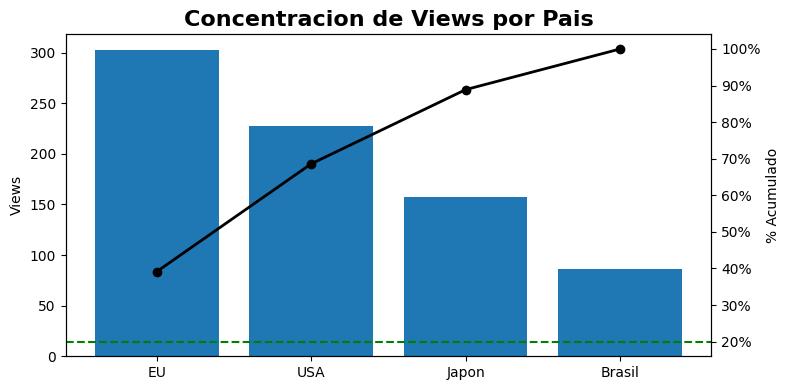

In [113]:

# PARETO - VIEWS POR PAIS

# Aqui estoy visualizando la concentracion de views
# por pais utilizando un grafico estilo Pareto.

# Primero agrupe las visualizaciones por pais
# y luego calcule el porcentaje acumulado
# para identificar mercados principales.


# Agrupar views por pais
pareto_df = (
    df_clean
    .groupby('Pais', as_index=False)['Views']
    .sum()
    .sort_values(by='Views', ascending=False)
)

# Calculo de porcentajes
pareto_df['pct_participacion'] = (
    pareto_df['Views'] / pareto_df['Views'].sum()
)

pareto_df['pct_acumulado'] = (
    pareto_df['pct_participacion'].cumsum()
)

# Configuracion visual
fig, ax1 = plt.subplots(figsize=(8,4))

# Barras principales
bars = ax1.bar(
    pareto_df['Pais'],
    pareto_df['Views'],
    color='#1f77b4'
)

# Linea acumulada
ax2 = ax1.twinx()

ax2.plot(
    pareto_df['Pais'],
    pareto_df['pct_acumulado'],
    color='black',
    marker='o',
    linewidth=2
)

# Linea referencia 20%
ax2.axhline(
    y=0.20,
    color='green',
    linestyle='--'
)

# Formato visual
ax1.set_title(
    'Concentracion de Views por Pais',
    fontsize=16,
    fontweight='bold'
)

ax1.set_ylabel('Views')
ax2.set_ylabel('% Acumulado')

ax2.yaxis.set_major_formatter(PercentFormatter(1))

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('pareto.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
#--GRAFICO PARETO - VIEWS POR PAIS

# Aqui genere un grafico estilo Pareto
# para visualizar la concentracion de visualizaciones
# por pais y el comportamiento del porcentaje acumulado.

# Las barras representan las views totales por pais,
# mientras que la linea muestra el porcentaje acumulado.

# Este tipo de visualizacion ayuda bastante
# para identificar rapidamente los mercados
# con mayor peso dentro del canal.

In [77]:
# Aqui estoy creando nuevas metricas
# para entender el comportamiento promedio
# de consumo por usuario en cada pais.


df_clean['Vistas_por_Usuario'] = (
    df_clean['Views'] / df_clean['QTY Usuarios']
)

df_clean['Tiempo_por_Usuario_Hrs'] = (
    df_clean['Watch Total time (hours)'] / df_clean['QTY Usuarios']
)

# Promedios por país
engagement_pais = (
    df_clean
    .groupby('Pais')[
        [
            'Vistas_por_Usuario',
            'Tiempo_por_Usuario_Hrs'
        ]
    ]
    .mean()
    .reset_index()
)

# Ordenar por mayor engagement
engagement_pais = (
    engagement_pais
    .sort_values(
        by='Tiempo_por_Usuario_Hrs',
        ascending=False
    )
)

# Formato opcional
engagement_pais['Vistas_por_Usuario'] = (
    engagement_pais['Vistas_por_Usuario']
    .round(2)
)

engagement_pais['Tiempo_por_Usuario_Hrs'] = (
    engagement_pais['Tiempo_por_Usuario_Hrs']
    .round(2)
)

# Resultado final
print(engagement_pais.head(10))

     Pais  Vistas_por_Usuario  Tiempo_por_Usuario_Hrs
1      EU                1.07                    0.07
3     USA                1.08                    0.05
2   Japon                0.93                    0.03
0  Brasil                0.95                    0.02


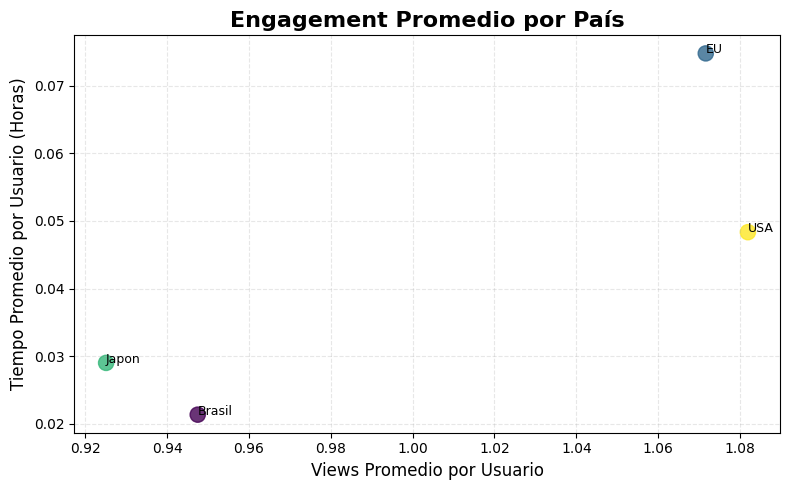

In [114]:
# Figura
plt.figure(figsize=(8, 5))

# Scatterplot
plt.scatter(
    engagement_country['Vistas_por_Usuario'],
    engagement_country['Tiempo_por_Usuario_Hrs'],
    s=120,
    c=range(len(engagement_country)),
    alpha=0.8
)

# Etiquetas
for i, row in engagement_country.iterrows():
    
    plt.text(
        row['Vistas_por_Usuario'],
        row['Tiempo_por_Usuario_Hrs'],
        row['Pais'],
        fontsize=9
    )

# Formato
plt.title(
    'Engagement Promedio por País',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Views Promedio por Usuario',
    fontsize=12
)

plt.ylabel(
    'Tiempo Promedio por Usuario (Horas)',
    fontsize=12
)

plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.savefig('EngagementPromedio.png', 
    dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
# Resumen del analisis de Engagement 
# En este grafico estoy comparando el comportamiento promedio de consumo por usuario en cada pais.

# El eje X representa las views promedio por usuario,
# mientras que el eje Y representa el tiempo promedio
# consumido por usuario en horas.

# Esto ayuda bastante para identificar mercados
# con mayor nivel de engagement y consumo de contenido.

# Durante el analisis se pudo observar que EU
# presenta el engagement mas alto,
# combinando tanto mayor consumo de videos
# como mayor tiempo promedio de visualizacion.

In [88]:
print(df_clean['Genre'].value_counts())

Genre
travel    15
film       6
Name: count, dtype: int64


In [ ]:
#En este bloque quise identificar los generos disponibles
# que quedaron luego de yo hacer la limpieza de los datos

In [ ]:
# CTR PROMEDIO POR PAIS Y GENERO

#aqui estoy agrupando  por paises y generos
ctr_country_genre = (
    df_clean
    .groupby(['Pais', 'Genre'])[
        'Impressions click-through rate (%)'
    ]
    .mean()
    .reset_index()
)

# En este bloque lo sorteo de mayor a menor
ctr_country_genre = ctr_country_genre.sort_values(
    by='Impressions click-through rate (%)',
    ascending=False
)

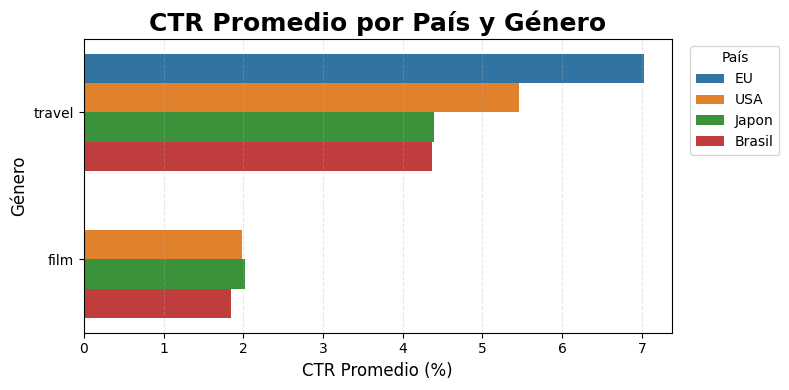

In [118]:

# Agrupación CTR por país y género
ctr_country_genre = (
    df_clean
    .groupby(['Pais', 'Genre'])[
        'Impressions click-through rate (%)'
    ]
    .mean()
    .reset_index()
    .sort_values(
        by='Impressions click-through rate (%)',
        ascending=False
    )
)

# Figura
plt.figure(figsize=(8, 4))

# Gráfico
sns.barplot(
    data=ctr_country_genre,
    y='Genre',
    x='Impressions click-through rate (%)',
    hue='Pais'
)

# Formato
plt.title(
    'CTR Promedio por País y Género',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'CTR Promedio (%)',
    fontsize=12
)

plt.ylabel(
    'Género',
    fontsize=12
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    title='País',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.savefig('barplotCTR.png', dpi=300, bbox_inches='tight')
plt.show()




In [93]:
# En este grafico estoy comparando el CTR promedio
# por pais y genero de contenido.

# El objetivo es identificar que tipo de contenido
# genera mayor nivel de atraccion inicial
# dependiendo del mercado.

# Durante el analisis se pudo observar
# que el genero "travel" presenta
# los CTR mas altos en la mayoria de paises,
# especialmente en EU y USA.

# Esto podria indicar una mayor afinidad
# de los usuarios hacia ese tipo de contenido,
# representando una posible oportunidad
# para futuras estrategias de marketing y crecimiento.

In [ ]:
# EVOLUCION TEMPORAL DE IMPRESIONES

# Agrupar impresiones por año y mes
impressions_trend = (
    df_clean
    .groupby(
        ['publish_year', 'publish_month']
    )['Impressions']
    .sum()
    .reset_index()
)

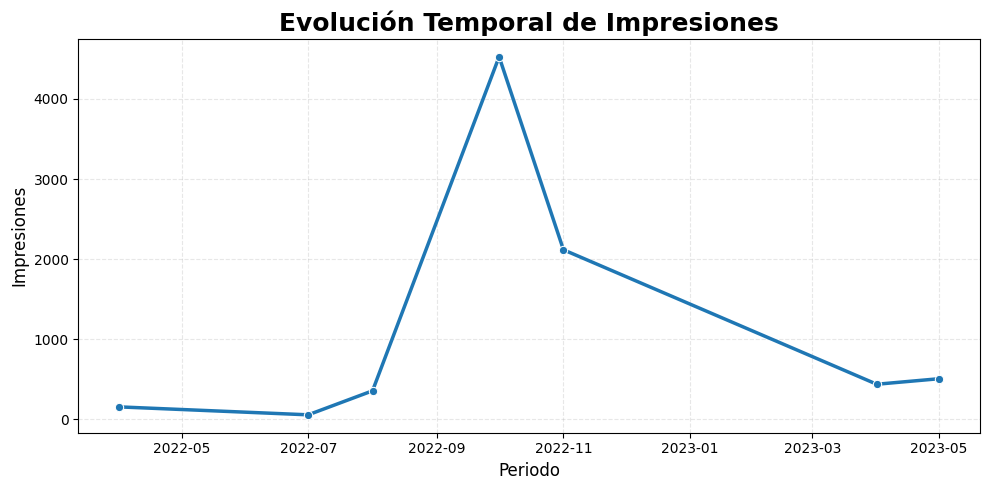

In [116]:
# Crear columnas temporales
df_clean['Year'] = df_clean['Video publish time'].dt.year
df_clean['Month'] = df_clean['Video publish time'].dt.month

# Agrupar impresiones por periodo
impressions_trend = (
    df_clean
    .groupby(['Year', 'Month'])['Impressions']
    .sum()
    .reset_index()
)

# Crear columna fecha
impressions_trend['Periodo'] = pd.to_datetime(
    impressions_trend[['Year', 'Month']]
    .assign(day=1)
)

# Ordenar
impressions_trend = (
    impressions_trend
    .sort_values('Periodo')
)

# Gráfico
plt.figure(figsize=(10,5))

sns.lineplot(
    data=impressions_trend,
    x='Periodo',
    y='Impressions',
    marker='o',
    linewidth=2.5
)

# Formato
plt.title(
    'Evolución Temporal de Impresiones',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Periodo', fontsize=12)
plt.ylabel('Impresiones', fontsize=12)

plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.savefig('Tendencia_temp.png', dpi=300, bbox_inches='tight')
plt.show()



In [ ]:
# En esta etapa analice el comportamiento historico
# de las impresiones a traves del tiempo
# utilizando las fechas de publicacion.

# El objetivo fue identificar posibles tendencias
# de crecimiento o desaceleracion del canal.

# Durante el analisis se observo un crecimiento fuerte
# en determinados periodos,
# seguido de una disminucion parcial,
# aunque manteniendo niveles superiores
# a los periodos iniciales.

# Esto podria indicar potencial de crecimiento
# y oportunidades de optimizacion
# mediante contenido y campañas estrategicas.

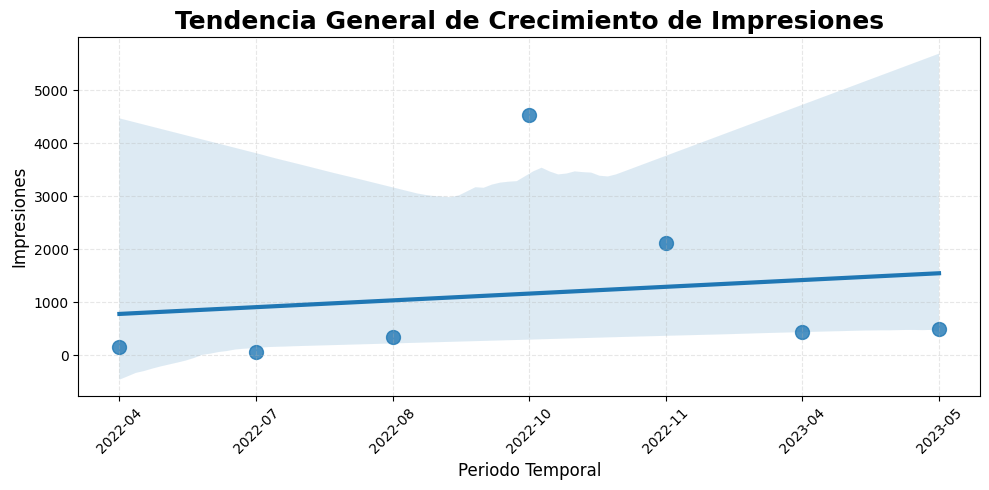

In [117]:
# Índice temporal
impressions_trend = impressions_trend.reset_index(drop=True)

impressions_trend['Time_Index'] = np.arange(
    len(impressions_trend)
)

# Gráfico de tendencia
plt.figure(figsize=(10, 5))

sns.regplot(
    data=impressions_trend,
    x='Time_Index',
    y='Impressions',
    scatter_kws={
        's': 100,
        'alpha': 0.8
    },
    line_kws={
        'linewidth': 3
    }
)

# Formato
plt.title(
    'Tendencia General de Crecimiento de Impresiones',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Periodo Temporal',
    fontsize=12
)

plt.ylabel(
    'Impresiones',
    fontsize=12
)

# Etiquetas de periodos
plt.xticks(
    impressions_trend['Time_Index'],
    impressions_trend['Periodo'].dt.strftime('%Y-%m'),
    rotation=45
)

plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.savefig('proyeccion_crecimiento.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# TENDENCIA GENERAL DE CRECIMIENTO

# En esta etapa complemente el analisis historico
# agregando una linea de tendencia general
# para estimar visualmente el posible crecimiento
# futuro de impresiones.

# Para esto cree un indice temporal numerico
# y posteriormente utilice un regplot
# para visualizar tanto los datos historicos
# como la direccion general de la tendencia.

# Durante el analisis se observa
# una tendencia ligeramente positiva,
# lo que podria indicar potencial
# de crecimiento futuro del canal.